In [1]:
%matplotlib inline
import sys
sys.path.append('../functions')
import numpy as np
#import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
#import torch
import pandas as pd
import multiprocessing
import time
from sklearn.model_selection import ParameterGrid
import linear_sim_func  

In [3]:
!python3 ../functions/main_linear.py

Runtime of the program is 0.10036563873291016 seconds


# One simulation 

In [2]:
N_v = [60]
N_test_v = [500]
p_v = [40]
error_sd_v = [1]
L_v = [0.9]
level_v = [0.2]
use_true_contour_v = [True]
n_boot_v = [2000]
ridge_penal_v = [[1,0.5,1e-1, 1e-2, 1e-3, 1e-4]]
#ridge_penal_v = [None]
MC_v = [False]
second_stage_v = [False]
center_G_v = [True]
center_pred_v = [True]
residual_boot_v = [False]
CV_boot_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,
              'ridge_penal':ridge_penal_v, 'MC':MC_v, 'second_stage':second_stage_v,
              'center_G':center_G_v, 'center_pred':center_G_v,
              'residual_boot':residual_boot_v, 'CV_boot':CV_boot_v}
param_grid = ParameterGrid(param_grid)
for param in param_grid:
    l = linear_sim_func.sim_linear(param['N'], param['N_test'], param['p'], param['error_sd'], 
                          param['L'],param['level'],param['use_true_contour'], param['n_boot'], 
                            param['ridge_penal'], param['MC'], param['second_stage'], 
                            param['center_G'], param['center_pred'], 
                            param['residual_boot'], param['CV_boot'])

> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(48)process_boot_samples()
     46     '''
     47     import pdb; pdb.set_trace()
---> 48     if MC:
     49         G = (mean_boot_l-mean_test_true)/se
     50     elif second_stage:



ipdb>  mean_boot_l.shape


(2000, 500)


ipdb>  n


> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(50)process_boot_samples()
     48     if MC:
     49         G = (mean_boot_l-mean_test_true)/se
---> 50     elif second_stage:
     51         mean_matrix, se = second_stage_boot(mean_boot_l)
     52         mean = np.mean(mean_boot_l, axis = 0)



...

> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(61)process_boot_samples()
     59             G = (mean_boot_l-mean)/se
     60         if center_pred:
---> 61             mean = np.mean(mean_boot_l, axis = 0)
     62     return G, mean, se
     63 



ipdb>  n


> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(62)process_boot_samples()
     60         if center_pred:
     61             mean = np.mean(mean_boot_l, axis = 0)
---> 62     return G, mean, se
     63 
     64 class cal_thres_at_q(object):



ipdb>  q


BdbQuit: 

In [ ]:
l

In [26]:
mae

0.610364083223544

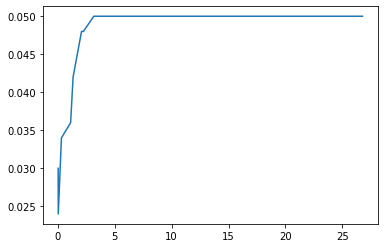

0.9500000000000028
0.974
True
0.752
0.9500000000000028
0.974
0.982
2


In [10]:
from matplotlib import pyplot as plt
x = [z[0] for z in range_v]
y = [z[1] for z in range_v]
plt.plot(x,y)
plt.show()
print(L)
print(U)
print(contain)
print(L1)
print(L2)
print(U1)
print(U2)
print(n_points)

# Multiple simulations (only works for MacOS)

In [4]:
from datetime import date
today = date.today()
date = today.strftime("%d%m%Y")
file_name = 'sim_results_boot_2000'+date+'.csv'
df_total = pd.DataFrame()
n_sim = 2
N_v = [50]
N_test_v = [500]
p_v = [160]
error_sd_v = [1]
L_v = [0.95]
level_v = [0.2]
use_true_contour_v = [False]
n_boot_v = [2000]
ridge_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,'ridge':ridge_v}
param_grid = ParameterGrid(param_grid)
start = time.time()
for param in param_grid:
    df = pd.DataFrame(param, index = [0])
    para_df = pd.DataFrame(np.repeat(df.values,n_sim, axis=0))
    para_df.columns = df.columns
    pool_obj = multiprocessing.Pool()
    cur_para = (n_sim*((param['N'], param['N_test'], param['p'], param['error_sd'], \
                      param['L'],param['level'],param['use_true_contour'], param['n_boot'], param['ridge']),))
    df_result.append(np.array(pool_obj.starmap(linear_sim_func.safe_sim_linear,cur_para)))
    pool_obj.close()
    pool_obj.join()
    df_ = pd.DataFrame(np.concatenate(df_result, axis = 0), 
                 columns = ["contain","contain_scb","contain_CS_scb","Lower_bound",
                            "Upper_bound", "L1", "L2", "U1", "U2", "points_in_e1", 
                            "pre_mae", 'inner_points_num', 'outer_points_num' ,'true_set_points_num'])
    df_ = pd.concat([para_df, df_], axis = 1)
    df_total = pd.concat([df_total,df_])
    df_total.to_csv(file_name, index = False)
end = time.time()
print('Runtime of the program is ' + str(end -start) + ' seconds')

ValueError: Shape of passed values is (2, 15), indices imply (2, 14)

In [ ]:
df_total[df_total.use_true_contour==0].mean()

# Using scripts to run (for Windows Ubuntun)

In [28]:
!python3 main.py

Runtime of the program is 281.3313100337982 seconds


# Bootstrap quantile vs True quantile

In [49]:
import bootstrap_func
from linear_sim_func import *
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
# bootstrap
N_test = 500
p = 40
beta =None
error_sd = 1
X_test = None
n_boot = 500
smoothed = False
residual_boot = False
sparsity = 0
#bias_correction = True
if beta is None:
    rng = np.random.default_rng(None)
    beta = rng.standard_normal(size = p)
    if sparsity > 0:
        index_zero = rng.choice(range(p), size= int(p*sparsity))
        beta[index_zero] = 0
y,X, X_test, mean_test_true = generate_linear_data(N = 100, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
penal_sizes = [5,2,1,0.5,1e-1, 1e-2, 1e-3, 1e-4]

In [50]:
N = 50
ridge_penal = True
CV_boot = True
second_stage = False
n_sample_mean = 100

In [51]:
y,X, _, _ = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
if ridge_penal is not None:
    mean, se, mean_boot_l, mean_train = bootstrap_func.fit_bootstrap_ridge(y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,  penal_sizes = penal_sizes, 
                                                               smoothed = smoothed, residual_boot = residual_boot, CV_boot = CV_boot)
else:# linear model without penality
    mean, se, mean_boot_l,mean_train = bootstrap_func.fit_bootstrap( y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot, smoothed = smoothed, residual_boot =  residual_boot)
if second_stage:
    mean = np.mean(mean_boot_l, axis = 0)
    mean_boot_l, se = bootstrap_func.second_stage_boot(mean_boot_l, n_sample = n_sample_mean)
mean_bias_cor1 = 2*mean - np.mean(mean_boot_l, axis = 0)
mean_bias_cor2 = mean - np.mean(mean_train - y)
# MCMC    
mean_MC_l = []
if second_stage:
    for i in range(n_boot):
        mean_MC_l_2 = []
        for j in range(n_sample_mean):
            y_new,X_new, X_test_trash, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
            if ridge_penal is not None:
                if CV_boot:
                    clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
                    mean_MC_l_2.append(clf.predict(X_test))
                else:
                    mean_MC_l_2.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
            else:# linear model without penality
                mean_MC_l_2.append(linear_fit_predict(y_new, X_new, X_test) )
        mean_MC_l.append(np.mean(mean_MC_l_2, axis = 0))
else:
    for i in range(n_boot):
        y_new,X_new, X_test_trash, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
        if ridge_penal is not None:
            if CV_boot:
                clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
                mean_MC_l.append(clf.predict(X_test))
            else:
                mean_MC_l.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
        else:# linear model without penality
            mean_MC_l.append(linear_fit_predict(y_new, X_new, X_test) )
mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
if smoothed:
    mean_MC = np.mean(mean_MC_l, axis = 0)
else:
    mean_MC = ridge_linear_fit_predict(y, X, X_test, ridge_penal) if ridge_penal is not None else linear_fit_predict(y, X, X_test) 

In [52]:
mean_train 

array([ 11.61319366,   5.58847294,  -1.05481799, -14.02105055,
         1.6538314 ,   4.27436328,   4.00469768,   2.45308193,
         1.50883597,  -5.84979811,   3.0771194 ,  -9.61468015,
        -2.08640957,  -0.99913764, -10.64017455,   5.05757005,
         3.60075208,  14.00147526,  -7.42741843,  -1.38699608,
         5.89242846,  -1.86865637,   3.60260616,   0.74271837,
         5.96634742,   0.71678785,  -3.12850546,  -3.94559743,
         3.28825126,  -2.54606984,   4.7962792 ,  12.23899416,
        10.91534412,   1.45203044,  -3.8416814 ,   3.77240552,
        -4.86951296,   5.13796091,  10.68886398,   1.79858535,
         9.64100166,  -2.25051913,   5.22711866,   5.3866047 ,
         2.53925753,   1.07487094,   0.44942219,  -4.14696512,
        -0.42973941,  -6.23598607])

In [53]:
y

array([ 12.63529659,   4.72880911,  -1.71886526, -14.46749705,
         1.78850531,   5.11578234,   3.69000386,   2.90221945,
         1.31581622,  -6.06301179,   3.67475616, -10.08704851,
        -2.24485664,  -0.7336113 , -10.90426791,   4.49689434,
         3.02274458,  14.31565081,  -6.99062962,  -1.24910821,
         5.66882596,  -1.55930453,   3.61634535,   0.0297039 ,
         6.42238574,   0.52998382,  -3.67771218,  -3.03811252,
         2.49412004,  -2.66953879,   5.09230247,  11.80203487,
        11.88084686,   0.58711909,  -3.95457699,   4.03857802,
        -5.22095759,   5.95165947,  11.88598751,   1.56781718,
         9.38504369,  -2.08332859,   5.08855405,   5.17621321,
         1.98724326,   0.66206043,   1.16544244,  -3.48240262,
        -0.97177929,  -5.78458045])

In [54]:
np.mean(np.abs(mean_train - y))

0.4569464998456546

In [55]:
mean_MC_l

array([[  5.59170497,  -6.26318014,  -5.74122816, ...,  -4.39530217,
          2.11815043,  -3.47534583],
       [  9.27894843,  -6.51296807,  -5.86583403, ...,  -5.19757288,
          4.28979475,  -3.36537331],
       [  8.5582169 ,  -8.90497022,  -5.2734519 , ...,  -4.08317081,
          3.8640727 ,  -1.34879722],
       ...,
       [  3.76610738,  -4.42481704,  -1.59396992, ...,  -2.79301799,
          6.01030187,  -1.6453193 ],
       [  7.30108111, -13.46411345,  -4.01971812, ...,  -0.69851437,
          5.2470215 ,  -2.86259246],
       [  6.26532818,  -9.77540163,  -5.80814133, ...,  -3.81887023,
          3.03797495,  -2.4044514 ]])

In [64]:
use_a_true = False
a_true = np.quantile(np.max(np.abs((mean_MC_l - mean_test_true)/se_MC),axis = 1), q = 0.975)
print(a_true)
minus_mean = np.mean(mean_boot_l, axis = 0)
#minus_mean = mean
a = np.quantile(np.max(np.abs((mean_boot_l - minus_mean)/se),axis = 1), q = 0.975)
print(a)
est = mean
#est = mean_bias_cor1
if use_a_true:
    print(np.all(np.logical_and(est+a_true*se>mean_test_true, est - a_true*se < mean_test_true)))
else:
    print(np.all(np.logical_and(est+a*se>mean_test_true, est - a*se < mean_test_true)))

4.583318747548904
4.102571429088789
True


In [57]:
est- mean_test_true

array([-2.40807517e+00,  1.68485229e+00,  8.41494513e-01,  5.72594736e-01,
        6.81716488e-01,  1.50227801e+00, -7.86742978e-01, -3.92615454e-01,
       -1.83763640e+00,  9.28747915e-05,  6.99528290e-01,  8.58177572e-01,
       -5.41855857e-01,  1.91350325e+00, -1.07674008e+00, -3.89953347e-01,
        2.19259106e+00,  3.57653468e-01,  2.43524218e+00, -7.55501202e-01,
       -1.35394489e-01, -1.34966704e+00,  2.35059520e-01,  8.96194941e-01,
       -3.23220398e+00, -6.04594483e-01, -1.35896824e+00, -9.17278138e-01,
        6.21342183e-01, -2.19167345e+00,  1.84851881e+00,  5.69370314e-01,
       -4.10387391e-02, -5.22981446e-01,  2.48153311e+00, -2.16057062e+00,
        1.46314738e+00,  9.85394351e-01, -2.14124045e+00, -1.52423095e+00,
       -2.43426759e-01, -6.49516622e-01, -2.60613336e-01,  1.11466891e+00,
       -1.66087506e+00, -1.03049045e+00, -2.55570598e+00,  3.06476899e+00,
        2.38892331e+00,  9.77803932e-02,  2.09018097e+00,  8.36307612e-01,
       -8.60284877e-01, -

In [65]:
a*se

array([ 9.93874445, 13.95025666, 10.13951048,  9.14911306,  5.71182562,
       11.29878157,  7.24250024,  9.45399335, 10.81202193, 14.09899512,
       12.46830451,  9.18077455,  6.95483591,  8.98203281,  8.90875303,
        6.91666747,  9.56545276,  7.41640801,  9.97822286,  8.30203498,
        9.7768541 , 10.16497953, 10.3184035 , 10.08173717,  8.7488055 ,
       12.30591117,  8.80797795,  8.24897374,  9.12690725,  7.23434533,
        8.04322866,  8.06979417, 11.74548063, 11.69360938,  9.58511129,
       10.21984085,  9.3948637 , 10.31109319,  9.13690564,  8.33733766,
        8.69706601,  9.32413605, 11.30965067, 10.43846647,  8.59227751,
       11.15429443,  9.7024679 ,  9.98894628,  8.02054341,  8.88245515,
        8.88467167, 14.91071007,  9.57793892,  9.8618557 , 11.8987087 ,
        8.62653918, 11.04313929, 11.67378464,  7.77651762,  7.74237064,
        7.73990076,  9.1390873 ,  8.16697006, 10.00651609, 10.57560612,
       10.9141056 , 10.79736042, 11.31944281, 10.73570497,  8.65

In [59]:
(mean_MC_l - mean_test_true)/se_MC

array([[-0.97319778,  1.33823383, -0.72377797, ..., -0.50928254,
        -1.3036883 , -0.37357578],
       [ 1.03615219,  1.22276592, -0.7951089 , ..., -0.94064249,
        -0.05996286, -0.3085773 ],
       [ 0.64339215,  0.11703002, -0.45599832, ..., -0.34145768,
        -0.30377873,  0.88330574],
       ...,
       [-1.96805057,  2.18804246,  1.65033003, ...,  0.3522237 ,
         0.92539117,  0.70804847],
       [-0.04167944, -1.99049665,  0.26170462, ...,  1.47838345,
         0.48825181, -0.01141223],
       [-0.60610925, -0.28533887, -0.76208258, ..., -0.19935018,
        -0.77689433,  0.2593688 ]])

In [60]:
np.mean(se_MC)

1.7059617637651217

In [61]:
np.mean(se)

2.3881732472914017

In [62]:
np.mean(np.abs(est - mean_test_true))

1.182847026737333

3.40036898819727
2.163267156244067
0.24196016374640167
-5.24607748542276
2.237809801078374
1.5985743339608842
7.077550851035472
5.432268471421378
2.477709335300949
1.8918636768016563
13.24593828010908
14.426647719851772
3.634479088810138
2.039859149753129
4.035985886407509
-1.2191819981294971
3.40036898819727
2.163267156244067
0.24196016374640167
-5.24607748542276
2.982623307912326
2.066264117339576
16.539366478038858
14.231213419681536
2.476729916685126
1.9710798324812042
5.238363959464272
5.074439419537603
2.3038256947550675
1.728113900028846
-0.19991656489750956
-0.8745593119309957


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:33: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.


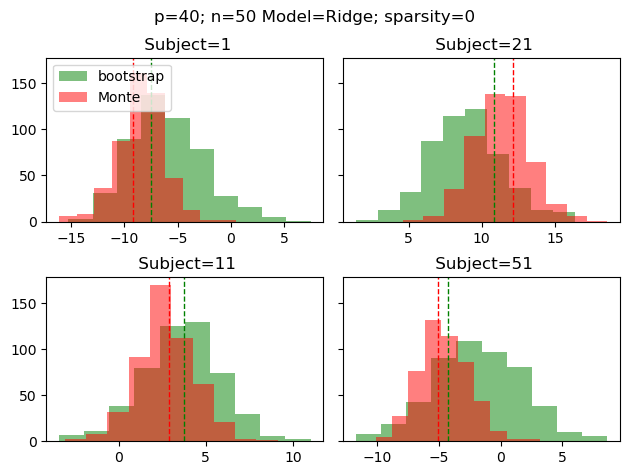

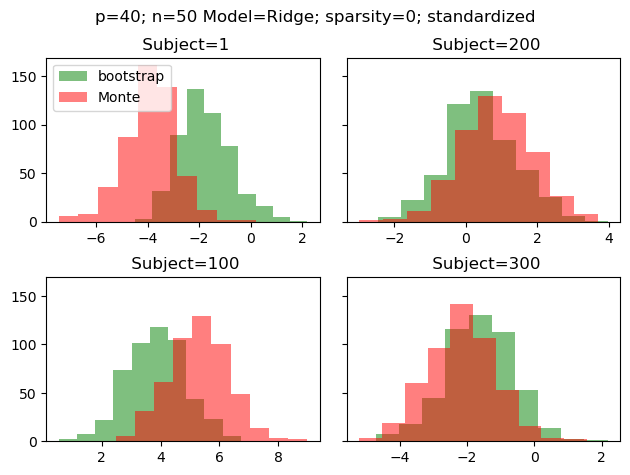

In [63]:
fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,11,21,51):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i], color = 'red', alpha=0.5, label = 'Monte')
    axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)
if second_stage:
    title = 'Second stage boot; '+ title
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')


fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,100,200,300):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i]/se[i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i]/se_MC[i], color = 'red', alpha=0.5, label = 'Monte')
    # axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    # #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    # axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)+'; standardized'
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')

# G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
# #np.mean(mean_boot_l,axis = 0)
# G_MC = (mean_MC_l-mean_test_true)/se_MC
# plt.hist(G[:,i], color = 'yellow', alpha=0.5)
# plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.show()
# print(np.std(G[:,i]))
# print(np.std(G_MC[:,i]))
# print(np.quantile(G[:,i], q = 0.95))
# print(np.quantile(G_MC[:,i], q = 0.95))
# print(np.quantile(G[:,i], q = 0.1))
# print(np.quantile(G_MC[:,i], q = 0.1))
# print(np.quantile(np.abs(G[:,i]), q = 0.95))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
# print(np.quantile(np.abs(G[:,i]), q = 0.1))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

In [442]:
print(np.mean(np.std(mean_boot_l, axis = 0) > np.std(mean_MC_l, axis = 0)))
print(np.mean(np.abs((np.std(mean_boot_l, axis = 0) - np.std(mean_MC_l, axis = 0)))))

0.02
0.7761519549930384


In [74]:
mean[16]

-19.21632190769464

In [432]:
np.mean(mean_boot_l, axis = 0)[16]

9.672344929039511

In [424]:
np.mean(mean_boot_l[:,i])

-6.330184772354789